In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Loading the dataset
df = pd.read_csv('fake_reviews_dataset.csv')


--- Class Distribution ---
label
CG    20216
OR    20216
Name: count, dtype: int64

Percentage:
 label
CG    50.0
OR    50.0
Name: proportion, dtype: float64


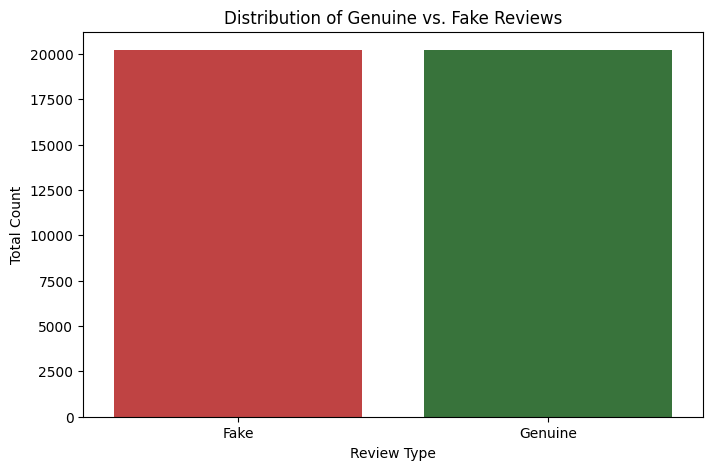

In [9]:
#Class balance check
print("\n--- Class Distribution ---")
class_counts = df['label'].value_counts()
print(class_counts)
print("\nPercentage:\n", df['label'].value_counts(normalize=True) * 100)

# Rename labels for a cleaner plot (OR = Genuine, CG = Fake)
df['label_name'] = df['label'].map({'OR': 'Genuine', 'CG': 'Fake'})

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label_name', hue='label_name', palette={'Genuine': '#2e7d32', 'Fake': '#d32f2f'}, legend=False)
plt.title('Distribution of Genuine vs. Fake Reviews')
plt.xlabel('Review Type')
plt.ylabel('Total Count')
plt.show()


--- Word Count Statistics by Class ---
              count       mean        std  min   25%   50%   75%    max
label_name                                                             
Fake        20216.0  61.288237  61.799015  1.0  19.0  35.0  77.0  318.0
Genuine     20216.0  73.642610  76.078420  5.0  23.0  42.0  93.0  373.0


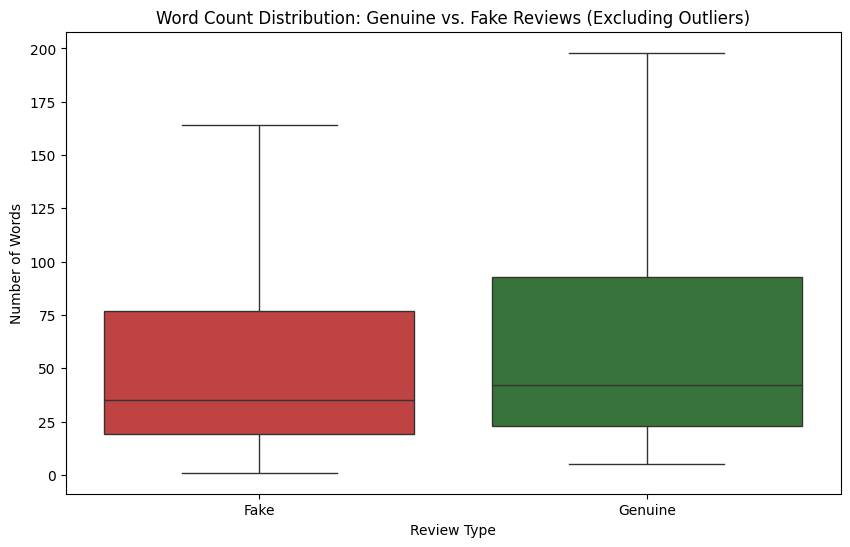

In [10]:
# Review length statistics

df['word_count'] = df['text_'].astype(str).apply(lambda x: len(x.split()))

print("\n--- Word Count Statistics by Class ---")
print(df.groupby('label_name')['word_count'].describe())

plt.figure(figsize=(10, 6))
# showfliers=False removes massive outliers so the boxplot is actually readable
sns.boxplot(data=df, x='label_name', y='word_count', hue='label_name', showfliers=False, palette={'Genuine': '#2e7d32', 'Fake': '#d32f2f'}, legend=False)
plt.title('Word Count Distribution: Genuine vs. Fake Reviews (Excluding Outliers)')
plt.xlabel('Review Type')
plt.ylabel('Number of Words')
plt.show()


--- Lexical Analysis: Top Bigrams (2-Word Phrases) ---


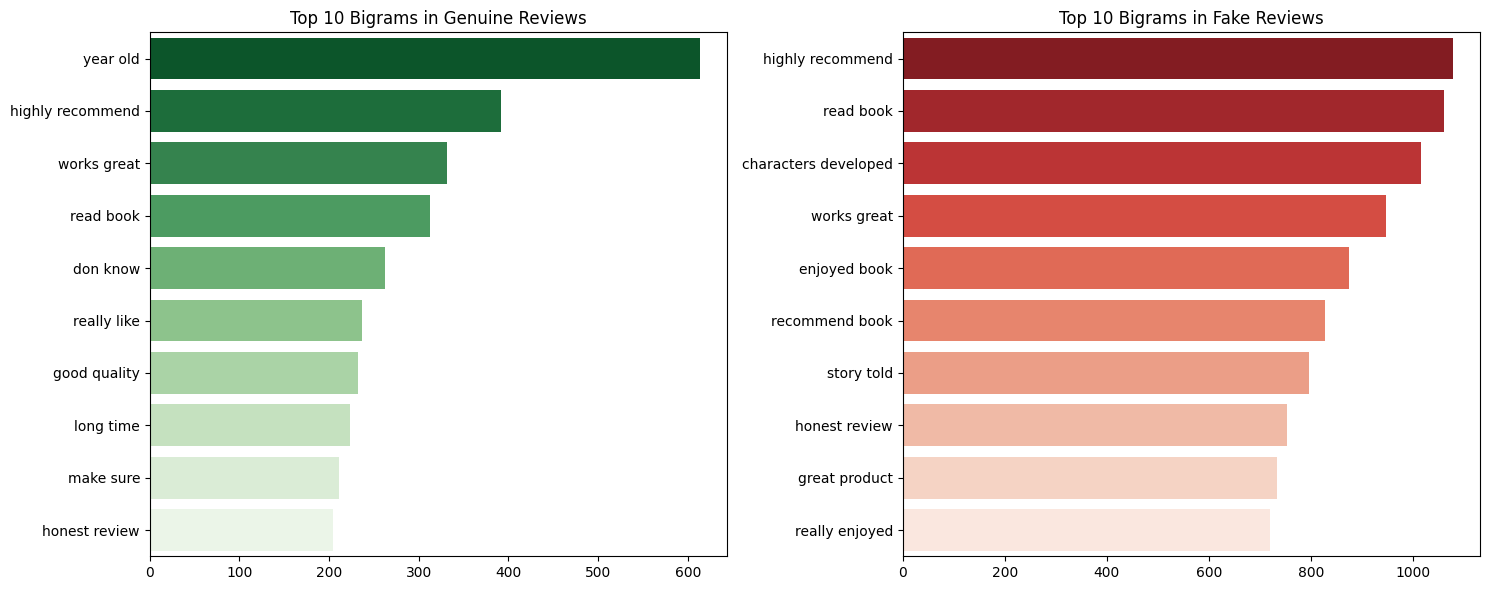

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

print("\n--- Lexical Analysis: Top Bigrams (2-Word Phrases) ---")

# Function to get top n-grams
def get_top_ngrams(corpus, n=None, ngram_range=(2,2)):
    vec = CountVectorizer(stop_words='english', ngram_range=ngram_range).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:n]

# Split corpus by class
genuine_text = df[df['label_name'] == 'Genuine']['text_'].dropna()
fake_text = df[df['label_name'] == 'Fake']['text_'].dropna()

top_genuine = get_top_ngrams(genuine_text, n=10)
top_fake = get_top_ngrams(fake_text, n=10)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(ax=axes[0], x=[x[1] for x in top_genuine], y=[x[0] for x in top_genuine], hue=[x[0] for x in top_genuine], palette='Greens_r', legend=False)
axes[0].set_title('Top 10 Bigrams in Genuine Reviews')

sns.barplot(ax=axes[1], x=[x[1] for x in top_fake], y=[x[0] for x in top_fake], hue=[x[0] for x in top_fake], palette='Reds_r', legend=False)
axes[1].set_title('Top 10 Bigrams in Fake Reviews')

plt.tight_layout()
plt.show()

In [8]:
from scipy import stats

print("\n--- Statistical Significance Test (Word Count) ---")

genuine_lengths = df[df['label_name'] == 'Genuine']['word_count'].dropna()
fake_lengths = df[df['label_name'] == 'Fake']['word_count'].dropna()

# We use Mann-Whitney U test because text lengths are rarely perfectly normally distributed
stat, p_value = stats.mannwhitneyu(genuine_lengths, fake_lengths, alternative='two-sided')

print(f"Mann-Whitney U Statistic: {stat}")
print(f"P-Value: {p_value}")

if p_value < 0.05:
    print("Conclusion: The difference in word counts between Genuine and Fake reviews is STATISTICALLY SIGNIFICANT (p < 0.05).")
else:
    print("Conclusion: There is NO statistically significant difference in word counts (p >= 0.05).")


--- Statistical Significance Test (Word Count) ---
Mann-Whitney U Statistic: 223296562.5
P-Value: 1.075388949159225e-58
Conclusion: The difference in word counts between Genuine and Fake reviews is STATISTICALLY SIGNIFICANT (p < 0.05).



--- Bridging the Gap: 2-Label Dataset to 4-Quadrant Product ---
Final_Product_Label
Promotional-style, Human-written    19801
Genuine-style, Human-written        19265
Genuine-style, AI-assisted            951
Promotional-style, AI-assisted        415
Name: count, dtype: int64


C:\Users\HP\AppData\Local\Temp\ipykernel_10092\606071931.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


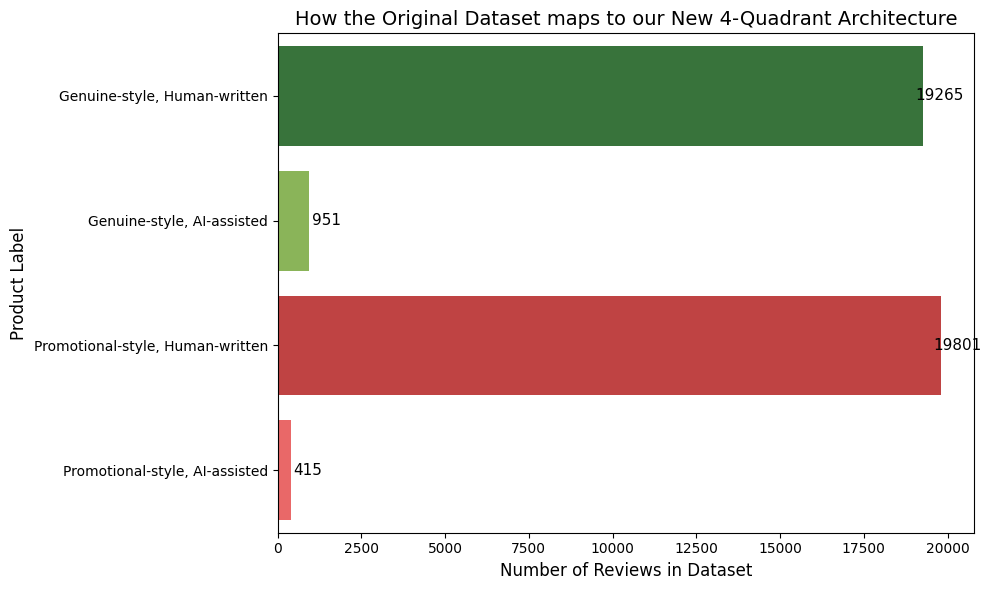

In [12]:
print("\n--- Bridging the Gap: 2-Label Dataset to 4-Quadrant Product ---")

# Step 1: Map the original dataset labels to Axis 1 (Transformer's Job)
# OR (Genuine) -> Genuine-style
# CG (Fake) -> Promotional-style
df['Axis_1_Style'] = df['label'].map({'OR': 'Genuine-style', 'CG': 'Promotional-style'})

# Step 2: Apply a simplified version of your Heuristic Engine (Axis 2)
# We will use Lexical Complexity (avg word length > 5.2 = AI) as a proxy
def get_axis_2_authorship(text):
    words = str(text).split()
    if len(words) == 0: return 'Human-written'
    
    avg_len = sum(len(w) for w in words) / len(words)
    
    # If the text is overly complex/dense, flag it as AI
    if avg_len > 5.2:
        return 'AI-assisted'
    else:
        return 'Human-written'

df['Axis_2_Authorship'] = df['text_'].apply(get_axis_2_authorship)

# Step 3: Combine them to create the exact 4 labels used in your Browser Extension!
df['Final_Product_Label'] = df['Axis_1_Style'] + ", " + df['Axis_2_Authorship']

# Step 4: Visualize the results!
print(df['Final_Product_Label'].value_counts())

plt.figure(figsize=(10, 6))
ax = sns.countplot(
    y=df['Final_Product_Label'], 
    order=['Genuine-style, Human-written', 'Genuine-style, AI-assisted', 
           'Promotional-style, Human-written', 'Promotional-style, AI-assisted'],
    palette=['#2e7d32', '#8bc34a', '#d32f2f', '#ff5252']
)

plt.title('How the Original Dataset maps to our New 4-Quadrant Architecture', fontsize=14)
plt.xlabel('Number of Reviews in Dataset', fontsize=12)
plt.ylabel('Product Label', fontsize=12)

# Add counts to the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', 
                (p.get_width() + 500, p.get_y() + p.get_height() / 2.), 
                ha='center', va='center', fontsize=11, color='black')

plt.tight_layout()
plt.show()

In [6]:
import pandas as pd

df = pd.read_csv("augmented_dataset.csv")

df.tail()

,category,rating,label,text_
41027,Sports_and_Outdoors_5,5.0,CG,"I usually shoot multiple weapons, but I though..."
41028,Electronics_5,5.0,OR,"Supper bright and litium battery, whats not to..."
41029,Clothing_Shoes_and_Jewelry_5,4.0,OR,Four stars for being cute asf However minuse o...
41030,Home_and_Kitchen_5,5.0,OR,Great for a playroom with multiple children. I...
41031,Tools_and_Home_Improvement_5,5.0,CG,"Looks great, made with quality material. The o..."
